In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("term-deposit-marketing-2020.csv")

df["y"] = df["y"].map({"no": 0, "yes": 1})

binary_cols = ["housing", "loan", "default"]  # example

for col in binary_cols:
    df[col] = df[col].map({"no": 0, "yes": 1})

#df["education"] = df["education"].map({"primary": 1, "secondary": 2, "tertiary": 3})

#df.replace("unknown", pd.NA, inplace=True)

#df["education"] = df["education"].map({"primary": 1, "secondary": 2, "tertiary": 3})

In [2]:
#df["education"] = df["education"].map({"primary": 1, "secondary": 2, "tertiary": 3})

In [3]:
print(df.shape)

(40000, 14)


In [4]:
print(df.head())

   age           job  marital  education  default  balance  housing  loan  \
0   58    management  married   tertiary        0     2143        1     0   
1   44    technician   single  secondary        0       29        1     0   
2   33  entrepreneur  married  secondary        0        2        1     1   
3   47   blue-collar  married    unknown        0     1506        1     0   
4   33       unknown   single    unknown        0        1        0     0   

   contact  day month  duration  campaign  y  
0  unknown    5   may       261         1  0  
1  unknown    5   may       151         1  0  
2  unknown    5   may        76         1  0  
3  unknown    5   may        92         1  0  
4  unknown    5   may       198         1  0  


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  str  
 2   marital    40000 non-null  str  
 3   education  40000 non-null  str  
 4   default    40000 non-null  int64
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  int64
 7   loan       40000 non-null  int64
 8   contact    40000 non-null  str  
 9   day        40000 non-null  int64
 10  month      40000 non-null  str  
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  int64
dtypes: int64(9), str(5)
memory usage: 4.3 MB
None


In [6]:
df.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
count,40000.000000,40000,40000,40000,40000.000000,40000.000000,40000.000000,40000.000000,40000,40000.000000,40000,40000.000000,40000.000000,40000.000000
unique,NaN,12,3,4,NaN,NaN,NaN,NaN,3,NaN,11,NaN,NaN,NaN
top,NaN,blue-collar,married,secondary,NaN,NaN,NaN,NaN,cellular,NaN,may,NaN,NaN,NaN
freq,NaN,9383,24386,20993,NaN,NaN,NaN,NaN,24914,NaN,13532,NaN,NaN,NaN
mean,40.544600,NaN,NaN,NaN,0.020225,1274.277550,0.600775,0.173250,NaN,16.017225,NaN,254.824300,2.882175,0.072400
std,9.641776,NaN,NaN,NaN,0.140771,2903.769716,0.489745,0.378468,NaN,8.278127,NaN,259.366498,3.239051,0.259152
min,19.000000,NaN,NaN,NaN,0.000000,-8019.000000,0.000000,0.000000,NaN,1.000000,NaN,0.000000,1.000000,0.000000
25%,33.000000,NaN,NaN,NaN,0.000000,54.000000,0.000000,0.000000,NaN,8.000000,NaN,100.000000,1.000000,0.000000
50%,39.000000,NaN,NaN,NaN,0.000000,407.000000,1.000000,0.000000,NaN,17.000000,NaN,175.000000,2.000000,0.000000
75%,48.000000,NaN,NaN,NaN,0.000000,1319.000000,1.000000,0.000000,NaN,21.000000,NaN,313.000000,3.000000,0.000000


In [7]:
df.describe(include=['object','string'])

,job,marital,education,contact,month
count,40000,40000,40000,40000,40000
unique,12,3,4,3,11
top,blue-collar,married,secondary,cellular,may
freq,9383,24386,20993,24914,13532


In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Series([], dtype: int64)


In [9]:
missing_percent = df.isnull().mean()
print(missing_percent * 100)

age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
y            0.0
dtype: float64


In [10]:
df.duplicated().sum()

np.int64(0)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'default'}>,
        <Axes: title={'center': 'balance'}>],
       [<Axes: title={'center': 'housing'}>,
        <Axes: title={'center': 'loan'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'y'}>]], dtype=object)

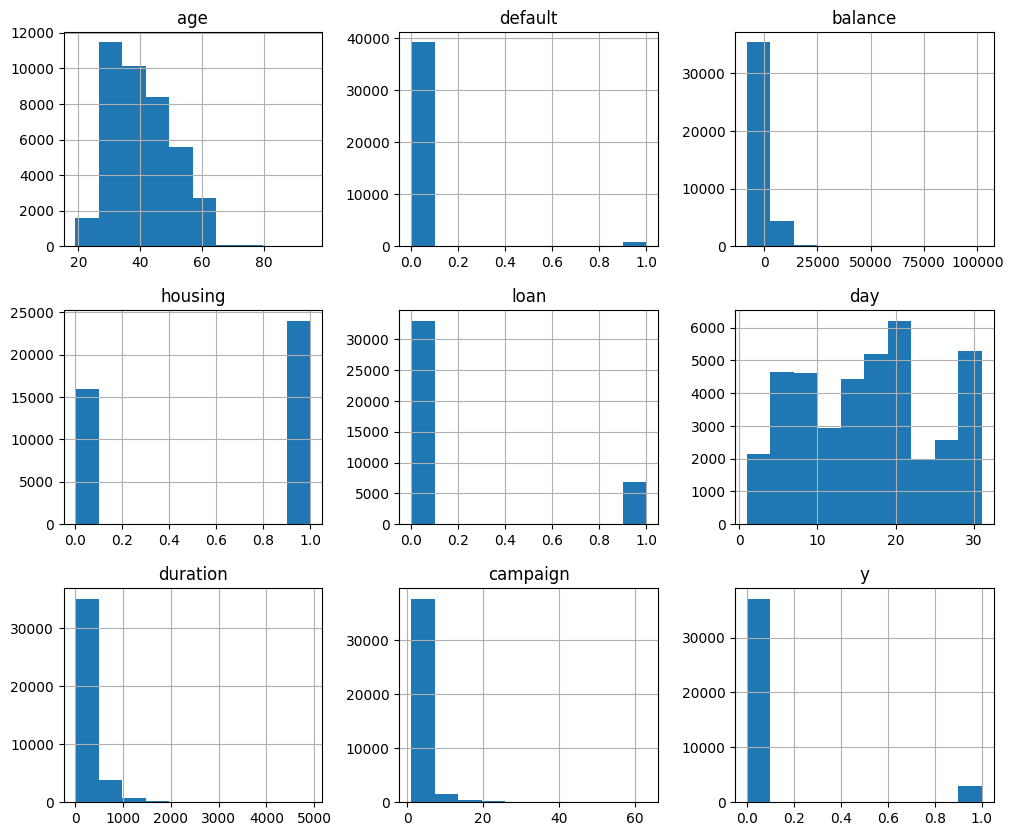

In [11]:
numeric = df.select_dtypes(include="number")

numeric.hist(figsize=(12,10))

In [12]:
corr = numeric.corr()

print(corr)

               age   default   balance   housing      loan       day  \
age       1.000000 -0.014857  0.081517 -0.179606  0.000041 -0.011689   
default  -0.014857  1.000000 -0.070069 -0.019229  0.075006  0.006287   
balance   0.081517 -0.070069  1.000000 -0.049946 -0.080596  0.011662   
housing  -0.179606 -0.019229 -0.049946  1.000000  0.004266 -0.050622   
loan      0.000041  0.075006 -0.080596  0.004266  1.000000  0.005838   
day      -0.011689  0.006287  0.011662 -0.050622  0.005838  1.000000   
duration -0.036270 -0.008597  0.014072  0.022455 -0.003952 -0.032983   
campaign  0.016204  0.012135 -0.008137 -0.054823  0.000582  0.165429   
y        -0.020273 -0.006559  0.030232 -0.054336 -0.031029 -0.006420   

          duration  campaign         y  
age      -0.036270  0.016204 -0.020273  
default  -0.008597  0.012135 -0.006559  
balance   0.014072 -0.008137  0.030232  
housing   0.022455 -0.054823 -0.054336  
loan     -0.003952  0.000582 -0.031029  
day      -0.032983  0.165429 -0.0

In [13]:
drop_cols = [
    "contact",
    "duration",
    "campaign",
    "month",
    "day"
]

demo_df = df.drop(columns=drop_cols)

In [14]:
demo_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  str  
 2   marital    40000 non-null  str  
 3   education  40000 non-null  str  
 4   default    40000 non-null  int64
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  int64
 7   loan       40000 non-null  int64
 8   y          40000 non-null  int64
dtypes: int64(6), str(3)
memory usage: 2.7 MB


In [15]:
demo_df.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,y
count,40000.000000,40000,40000,40000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
unique,NaN,12,3,4,NaN,NaN,NaN,NaN,NaN
top,NaN,blue-collar,married,secondary,NaN,NaN,NaN,NaN,NaN
freq,NaN,9383,24386,20993,NaN,NaN,NaN,NaN,NaN
mean,40.544600,NaN,NaN,NaN,0.020225,1274.277550,0.600775,0.173250,0.072400
std,9.641776,NaN,NaN,NaN,0.140771,2903.769716,0.489745,0.378468,0.259152
min,19.000000,NaN,NaN,NaN,0.000000,-8019.000000,0.000000,0.000000,0.000000
25%,33.000000,NaN,NaN,NaN,0.000000,54.000000,0.000000,0.000000,0.000000
50%,39.000000,NaN,NaN,NaN,0.000000,407.000000,1.000000,0.000000,0.000000
75%,48.000000,NaN,NaN,NaN,0.000000,1319.000000,1.000000,0.000000,0.000000


In [16]:
demo_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
y            0
dtype: int64

In [17]:
demo_df.head()

,age,job,marital,education,default,balance,housing,loan,y
0,58,management,married,tertiary,0,2143,1,0,0
1,44,technician,single,secondary,0,29,1,0,0
2,33,entrepreneur,married,secondary,0,2,1,1,0
3,47,blue-collar,married,unknown,0,1506,1,0,0
4,33,unknown,single,unknown,0,1,0,0,0


In [18]:
for col in demo_df.columns:
    print(f"\n{col}:")
    print(demo_df[col].value_counts(dropna=False))


age:
age
32    1909
31    1826
33    1770
34    1730
35    1721
      ... 
90       1
94       1
86       1
95       1
81       1
Name: count, Length: 70, dtype: int64

job:
job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64

marital:
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64

education:
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64

default:
default
0    39191
1      809
Name: count, dtype: int64

balance:
balance
0         3209
1          179
2          141
4          126
3          124
          ... 
2694         1
4545         1
7222         1
3402         1
102127       1
Name: count, Length: 6849, dtype: int64

housing:
housing
1 

In [19]:
df["y"].value_counts()

y
0    37104
1     2896
Name: count, dtype: int64

In [20]:
df["y"].value_counts(normalize=True)

y
0    0.9276
1    0.0724
Name: proportion, dtype: float64

In [21]:
pd.crosstab(df["job"], df["y"], normalize="index")

y,0,1
job,,
admin,0.921704,0.078296
blue-collar,0.942982,0.057018
entrepreneur,0.937367,0.062633
housemaid,0.951242,0.048758
management,0.917218,0.082782
retired,0.894920,0.105080
self-employed,0.920792,0.079208
services,0.939130,0.060870
student,0.843511,0.156489


In [22]:
pd.crosstab(df["marital"], df["y"], normalize="index")

y,0,1
marital,,
divorced,0.917249,0.082751
married,0.939391,0.060609
single,0.905685,0.094315


In [23]:
pd.crosstab(df["education"], df["y"], normalize="index")

y,0,1
education,,
primary,0.943700,0.056300
secondary,0.932454,0.067546
tertiary,0.908174,0.091826
unknown,0.937296,0.062704


In [24]:
pd.crosstab(df["default"], df["y"], normalize="index")

y,0,1
default,,
0,0.927356,0.072644
1,0.939431,0.060569


In [25]:
pd.crosstab(df["loan"], df["y"], normalize="index")

y,0,1
loan,,
0,0.923919,0.076081
1,0.945166,0.054834


In [26]:
pd.crosstab(df["housing"], df["y"], normalize="index")

y,0,1
housing,,
0,0.910326,0.089674
1,0.939079,0.060921


In [27]:
df.groupby("y")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,37104.0,40.599208,9.525450,19.0,33.0,39.0,48.0,94.0
1,2896.0,39.844959,11.001984,19.0,31.0,37.0,47.0,95.0


In [28]:
df.groupby("y")["balance"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,37104.0,1249.752533,2900.722436,-8019.0,50.0,395.0,1286.0,102127.0
1,2896.0,1588.495856,2924.894429,-3058.0,141.0,620.0,1820.5,45248.0


In [51]:
pd.crosstab(
    [df["job"], df["marital"]],
    df['education'],
    normalize=False #"index"
)

education               primary  secondary  tertiary  unknown
job           marital                                        
admin         divorced       29        590        43       18
              married       143       1931       172       87
              single         30       1202       195       43
blue-collar   divorced      313        378         2       37
              married      2859       3533        57      310
              single        501       1233        68       92
entrepreneur  divorced        9         61        89        6
              married       149        382       430       57
              single         18         64       129       11
housemaid     divorced       76         60        18        6
              married       444        237       100       29
              single         35         48        29        5
management    divorced       25        137       831       25
              married       229        630      3710      122
              single         19        270      2126       42
retired       divorced       90        112        64        5
              married       372        510       151       49
              single         23         42        14        5
self-employed divorced        6         54        63        1
              married       111        393       397       18
              single         12        105       242       12
services      divorced       59        443        13       19
              married       225       1902        82       86
              single         52        924        75       30
student       divorced        1          1         2        0
              married         2         13        18        7
              single         15        268       130       67
technician    divorced       17        674       166       19
              married       116       2629       761      133
              single         15       1485       775       62
unemployed    divorced       23        101        23        1
              married       152        366       104       13
              single         55        155       101       10
unknown       divorced        4          3         3        5
              married        34         34        17       80
              single          7         23         6       19

In [43]:
pd.crosstab(
    df["education"], df["job"],
    #df['y'],
    normalize=False #"index"
)

job,admin,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
education,,,,,,,,,,,,
primary,202,3673,176,555,273,485,129,336,18,148,230,45
secondary,3723,5144,507,345,1037,664,552,3269,282,4788,622,60
tertiary,410,127,648,147,6667,229,702,170,150,1702,228,26
unknown,148,439,74,40,189,59,31,135,74,214,24,104


In [52]:
df.groupby(["job","education"])["y"].value_counts(normalize=True)

job      education  y
admin    primary    0    0.955446
                    1    0.044554
         secondary  0    0.922912
                    1    0.077088
         tertiary   0    0.880488
                           ...   
unknown  secondary  1    0.083333
         tertiary   0    0.961538
                    1    0.038462
         unknown    0    0.913462
                    1    0.086538
Name: proportion, Length: 96, dtype: float64

In [53]:
df.groupby(["job","education"])["y"].mean()

job            education
admin          primary      0.044554
               secondary    0.077088
               tertiary     0.119512
               unknown      0.040541
blue-collar    primary      0.049279
               secondary    0.060848
               tertiary     0.118110
               unknown      0.059226
entrepreneur   primary      0.056818
               secondary    0.069034
               tertiary     0.057099
               unknown      0.081081
housemaid      primary      0.048649
               secondary    0.040580
               tertiary     0.068027
               unknown      0.050000
management     primary      0.040293
               secondary    0.067502
               tertiary     0.087146
               unknown      0.074074
retired        primary      0.105155
               secondary    0.084337
               tertiary     0.170306
               unknown      0.084746
self-employed  primary      0.031008
               secondary    0.063406
             

In [54]:
from itertools import combinations

cat_cols = [
    "job",
    "education",
    "marital",
    "housing",
    "loan"
]

#for c1, c2 in combinations(cat_cols, 2):
#    print(f"\n{c1} × {c2}")
#    print(df.groupby([c1, c2])["y"].mean())

for i, j in combinations(cat_cols, 2):
    print(f"\n{i} ; {j}:")
    print(df.groupby([i,j])['y'].agg(['count', 'mean']))#.sort_values('mean', ascending=False))


#summary = (
#    df.groupby(["job", "education"])["y"]
#      .agg(["count", "mean"])
#      .sort_values("mean", ascending=False)
#)

#print(summary)


job ; education:
                         count      mean
job           education                 
admin         primary      202  0.044554
              secondary   3723  0.077088
              tertiary     410  0.119512
              unknown      148  0.040541
blue-collar   primary     3673  0.049279
              secondary   5144  0.060848
              tertiary     127  0.118110
              unknown      439  0.059226
entrepreneur  primary      176  0.056818
              secondary    507  0.069034
              tertiary     648  0.057099
              unknown       74  0.081081
housemaid     primary      555  0.048649
              secondary    345  0.040580
              tertiary     147  0.068027
              unknown       40  0.050000
management    primary      273  0.040293
              secondary   1037  0.067502
              tertiary    6667  0.087146
              unknown      189  0.074074
retired       primary      485  0.105155
              secondary    664  0.08433